**学号：**`23344072`

**姓名：**`贾梓杏`

**Week One**

## 研究`digit`数据集
- 尝试Plot并观察数据集
- 用`knn,LR`拟合数据，观察表现、泛化能力
- 绘制`knn`的学习曲线

### Step One:库导入and实例化

In [ ]:
from sklearn import neighbors,datasets,metrics,model_selection,linear_model
import matplotlib.pyplot as plt
import numpy as np
datad = datasets.load_digits()
model = neighbors.KNeighborsClassifier()

### Step Two:了解数据集结构
- 注意`.shape`一般是对`numpy`和`pandas`的数据结构才能用的
- 从`shape`能看出image和data分别是展平前后的。 

In [2]:
print(datad.keys())
print(datad.images.shape)
print(datad.data.shape)
print(len(datad.target))
print(datad.target_names)


dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 8, 8)
(1797, 64)
1797
[0 1 2 3 4 5 6 7 8 9]


### Step Three：绘制1-9的图像

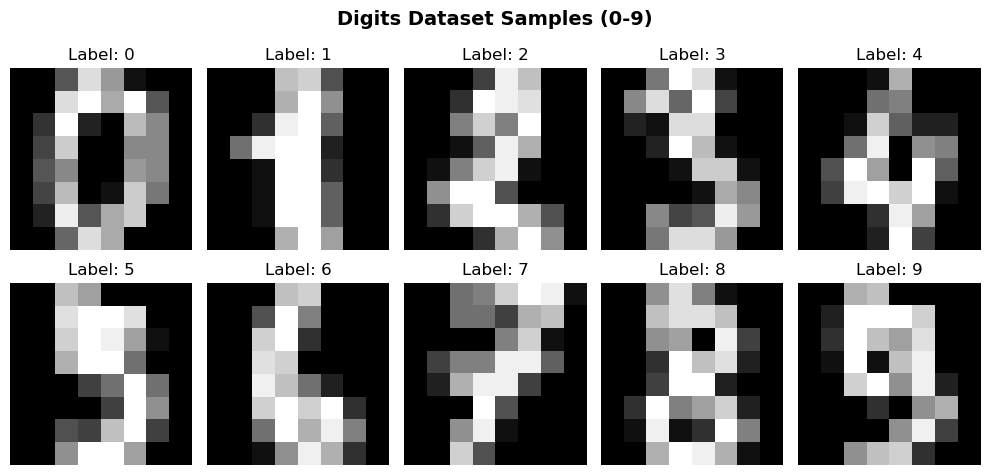

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle('Digits Dataset Samples (0-9)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # 找到每个数字的第一个样本
    idx = np.where(datad.target == i)[0][0]
    ax.imshow(datad.images[idx], cmap='gray')
    ax.set_title(f'Label: {i}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step Four：拟合与泛化（KNN）

In [4]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(datad.data, datad.target, test_size=0.3)
model.fit(X_train,y_train)
model_prediction_fit = model.predict(X_train)
model_prediction_gene = model.predict(X_test)
AR_fit = metrics.accuracy_score(y_train,model_prediction_fit)
AR_gene = metrics.accuracy_score(y_test,model_prediction_gene)
print(f"训练表现{AR_fit}")
print(f"泛化表现{AR_gene}")

训练表现0.9896579156722355
泛化表现0.9833333333333333


### Step Five：Learning Curve（KNN）
- `train_scores.shape = (train_sizes,cv)`，所以需要先取平均

(8, 5)


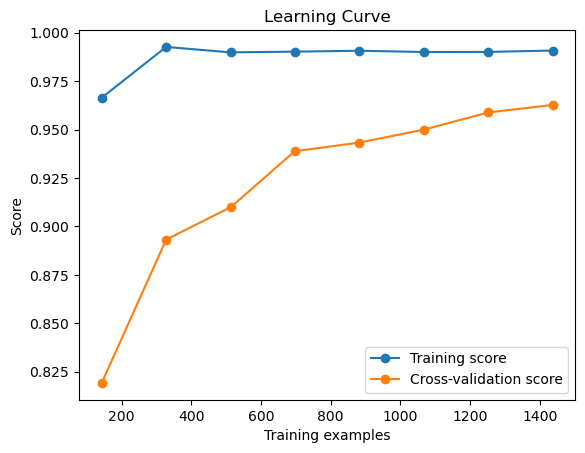

In [5]:
train_sizes, train_scores, test_scores = model_selection.learning_curve(
    model, datad.data, datad.target,
    train_sizes=np.linspace(0.1, 1.0, 8), 
    cv=5
)
print(train_scores.shape)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Score')
plt.legend()
plt.title('Learning Curve')
plt.show()

### Step Six：拟合与泛化（LR）
- 这里有一个有趣的现象，如果`max_iter`较小，会出现无法收敛的情况

In [8]:
model_linear = linear_model.LogisticRegression(max_iter=1000)
model_linear.fit(X_train,y_train)
model_LR_prediction_fit = model_linear.predict(X_train)
model_LR_prediction_gene = model_linear.predict(X_test)
AR_fit_LR = metrics.accuracy_score(y_train,model_LR_prediction_fit)
AR_gene_LR = metrics.accuracy_score(y_test,model_LR_prediction_gene)
print(f"训练表现{AR_fit_LR}")
print(f"泛化表现{AR_gene_LR}")


训练表现1.0
泛化表现0.9518518518518518


### 使用CNN做一个简单的MINIST分类

In [ ]:
# 1) 导入依赖
import torch
print(f"torch version:{torch.__version__}")
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 2) 选择设备（有GPU就用GPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 3) 加载小型现成数据集：MNIST（手写数字）
transform = transforms.ToTensor()
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

# 4) 定义一个非常简单的CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 14x14 -> 7x7
        )
        self.classifier = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 5) 训练（为了演示简洁，这里只跑2个epoch）
for epoch in range(2):
    model.train()
    running_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_set)
    print(f"Epoch {epoch+1}/2, train loss: {train_loss:.4f}")

# 6) 测试准确率
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()

acc = correct / len(test_set)
print(f"Test Accuracy: {acc:.4f}")

## 课堂知识总结
---
### Part One:`Dataset`

- `from sklearn import datasets`:`datasets`是`Scikit-learn` 库中专门用于提供内置数据集的模块，主要分为 3 类
   1. Toy Datasets（常用如鸢尾花数据集`load_iris()`，多分类任务；手写数字数据集	`load_digits()`，多分类任务）
   2. Real World Datasets(这类数据集更贴近真实业务场景，体积稍大，需通过网络下载（首次使用时自动下载）)
   3. Generated Datasets（通过函数人工生成符合特定规律的数据集，用于测试算法的边界情况（如非线性、噪声、类别不平衡））
- 数据格式：数据格式：所有加载的数据集均为Bunch 对象（类似字典），可通过 `.keys()` 查看所有属性：

### Part Two:算法
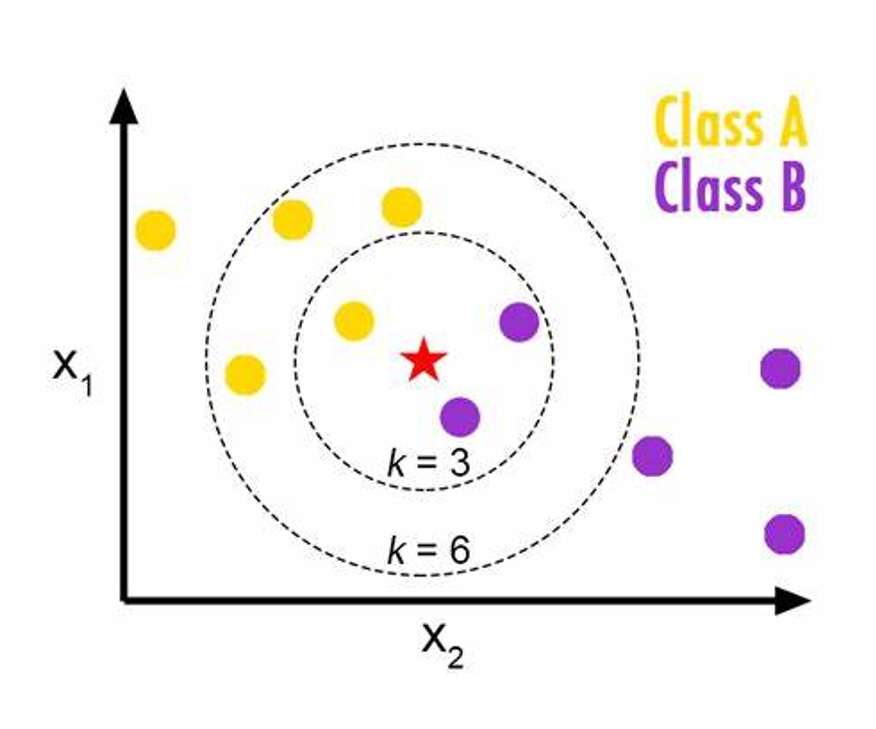
- 对于`KNN`的理解：`KNN`实际上是一个过于简单粗暴的算法，甚至我都不愿意称之为`Model`。所谓的训练过程其实只是存储数据的过程。
- `from sklearn import neighbors`:`sklearn.neighbors` 是 `Scikit-learn` 库中专门实现近邻算法的核心模块，涵盖了 K 近邻（KNN）、近邻回归、近邻聚类、异常检测等一系列基于 “距离 / 近邻” 思想的算法，是机器学习中最基础也最实用的模块之一。使用`KNN`的方法也非常简单：`model = neighbors.KNeighborsClassifier()`
- 实例化后的 `model`（KNN 分类器对象）提供了一系列可调用的方法（函数），这些方法覆盖了模型训练、预测、评估、参数查看 / 修改等全流程:

    <table align="center">
    <thead>
    <tr>
    <th>方法名</th>
    <th>用途</th>
    <th>语法示例</th>
    <th>关键说明</th>
    </tr>
    </thead>
    <tbody>
    <tr>
    <td>fit(X, y)</td>
    <td>训练模型（KNN 是惰性学习，实际仅存储训练数据）</td>
    <td>model.fit(X_train, y_train)</td>
    <td>必须先调用fit()，才能使用predict/score等方法</td>
    </tr>
    <tr>
    <td>predict(X)</td>
    <td>预测样本的类别标签</td>
    <td>y_pred = model.predict(X_test)</td>
    <td>返回一维数组，每个元素是对应样本的预测类别</td>
    </tr>
    <tr>
    <td>predict_proba(X)</td>
    <td>预测样本属于每个类别的概率</td>
    <td>proba = model.predict_proba(X_test)</td>
    <td>返回二维数组（行数 = 样本数，列数 = 类别数），值为概率（和为 1）</td>
    </tr>
    <tr>
    <td>score(X, y)</td>
    <td>计算模型在数据集上的准确率</td>
    <td>acc = model.score(X_test, y_test)</td>
    <td>返回 0~1 之间的浮点数，越大表示模型效果越好</td>
    </tr>

    </tbody>
    </table>

---
- `from sklearn import linear_model`:linear_model 是 scikit-learn 中的线性模型模块，包含多种用于回归和分类的算法，如：
  | 类/函数                 | 用途         | 特点           |
  | -------------------- | ---------- | ------------ |
  | `LinearRegression`   | 线性回归       | 最小二乘法，无正则化   |
  | `Ridge`              | 岭回归        | L2正则化，防止过拟合  |
  | `Lasso`              | Lasso回归    | L1正则化，自动特征选择 |
  | `ElasticNet`         | 弹性网络       | L1+L2正则化结合   |
  | `LogisticRegression` | **逻辑回归分类** | 线性分类器，输出概率   |
  | `SGDClassifier`      | 随机梯度下降分类   | 大规模数据适用      |
  | `SGDRegressor`       | 随机梯度下降回归   | 大规模数据适用      |
  | `Perceptron`         | 感知机        | 最简线性分类器      |

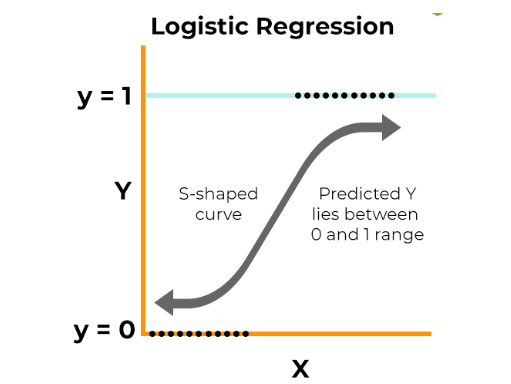
- 第二个算法是Logistic Regression，虽然名字里有"回归"，但它实际上是分类算法。这个算法也是相当的简单粗暴，将线性输出通过 Sigmoid函数 映射到 (0,1) 概率。一般而言，$P = 0.5$就是判断为正类负类的关键。但是，这个算法和KNN有本质区别了：KNN是一个非参数化的模型，但是`LR`是内部有参数的，所以如果调用`model.fit()`实际上实会优化模型内部的参数$W,b$的。一旦参数优化完成，进行前向过程就只需要$WX+b$，再经过一个Sigmoid就完成了LR。


- 实例化`model = linear_model.`后，有哪些函数用法：
  | 方法                 | 用途       | 返回值                          |
  | ------------------ | -------- | ---------------------------- |
  | `fit(X, y)`        | 训练模型     | `self`                         |
  | `predict(X)`       | 预测类别标签   | 形状 `(n_samples,)`            |
  | `predict_proba(X)` | 预测概率     | 形状 `(n_samples, n_classes)`  |
  | `score(X, y)`      | 准确率评估    | float                        |



### Part Three：Evaluation
- `from sklearn import model_selection`:功能见下表
  | 常用功能      | 函数/类                                                       | 作用               | 常用参数说明                                                                                                                                   |
  | --------- | ---------------------------------------------------------- | ---------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
  | **数据划分**  | `train_test_split(X, y, **kwargs)`                         | 将数据拆分为训练集/测试集    | `test_size=0.2` — 测试集比例（0-1之间或具体数量）<br>`random_state=42` — 随机种子，保证结果可复现<br>`shuffle=True` — 划分前是否打乱数据<br>`stratify=y` — 按标签比例分层抽样（分类任务推荐） |
  | **交叉验证**  | `cross_val_score(model, X, y, **kwargs)`                   | K折交叉验证评估模型稳定性    | `cv=5` — 折数（int）或交叉验证生成器<br>`scoring='accuracy'` — 评分指标（如'roc\_auc', 'f1'）<br>`n_jobs=-1` — 并行作业数，-1使用全部CPU    。返回一个`ndarray` — 每折的评分结果,长度为`cv`                           |                                                                                              
  | **超参数搜索** | `GridSearchCV(model, param_grid, **kwargs)`                | 网格搜索最优参数组合       | `param_grid={'C':[0.1,1,10]}` — 参数字典<br>`cv=5` — 交叉验证折数<br>`scoring='accuracy'` — 评估指标<br>`n_jobs=-1` — 并行计算<br>`verbose=2` — 输出详细日志      |
  | **选择器**   | `learning_curve(model, X, y, **kwargs)`                    | 绘制学习曲线，诊断过拟合/欠拟合 | `train_sizes=np.linspace(0.1, 1.0, 10)` — 训练集比例<br>`cv=5` — 交叉验证折数<br>`scoring='accuracy'` — 评估指标<br>`n_jobs=-1` — 并行计算                   |

- `from sklearn import  metrics`:功能见下表
  | 任务类型   | 常用指标                                          | 说明         |
  | ------ | --------------------------------------------- | ---------- |
  | **分类** | `accuracy_score`                              | 准确率        |
  |        | `precision_score(y_true,y_pred)`, `recall_score(y_true,y_pred)`, `f1_score` | 精确率、召回率、F1 |
  |        | `confusion_matrix`                            | 混淆矩阵       |
  | **回归** | `mean_squared_error` (MSE)                    | 均方误差       |
  |        | `mean_absolute_error` (MAE)                   | 平均绝对误差     |
  |        | `r2_score`                                    | 决定系数 R²    |
  | **聚类** | `silhouette_score`                            | 轮廓系数       |
  
  混淆矩阵定义如下：
  ```bash
                  预测为正类(1)    预测为负类(0)
  实际为正类(1)      TP (真正例)      FN (假反例)
  实际为负类(0)      FP (假正例)      TN (真反例)
  ```
  为什么`precision_score`要强调一下`(y_true,y_pred)`？因为不能换序

### Part Four:PLOT

---
## 课上代码
上面的部分为作业或总结，下面为课上代码。因为原本在其它脚本中，故一次性copy到该作业脚本中。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets,neighbors,metrics,model_selection
iris_data = datasets.load_iris()
X,y = iris_data.data, iris_data.target
df = pd.DataFrame(data= np.column_stack([X,y]), columns=iris_data.feature_names + ['class'])
sns.pairplot(df, hue='class')
model = neighbors.KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

print('Accuracy on the train sample: ', metrics.accuracy_score( model.predict(X_train), y_train))
print('Accuracy on the test  sample: ', metrics.accuracy_score( model.predict(X_test), y_test))
model_selection.cross_validate(model, X,y, cv=5, scoring='accuracy' )
n = np.arange(len(X))
np.random.shuffle(n)
model_selection.cross_val_score(model, X[n], y[n], cv=5)
## 超参数n的影响
n = np.arange(len(X))
np.random.shuffle(n)
X,y = X[n], y[n]
val_scores =[]
for n_neighbors in range(1,60):
    model = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors)
    val_scores.append(model_selection.cross_val_score(model, X, y, cv=5))
plt.plot(range(1,60), [np.mean(xx) for xx in val_scores], lw=2, marker='o', c='k')
train_scores, test_scores =model_selection.validation_curve(neighbors.KNeighborsClassifier(), X, y,  param_name='n_neighbors', param_range=range(1,60), cv=5)
train_scores
train_scores, test_scores =model_selection.validation_curve(neighbors.KNeighborsClassifier(), X, y,  param_name='n_neighbors', param_range=range(1,60), cv=5)
train_scores, test_scores =train_scores.mean(axis=1), test_scores.mean(axis=1)
plt.plot(range(1,60), test_scores, lw=2, marker='o', c='k', label = 'test_scores (fitting error + generalization error)')
plt.plot(range(1,60), train_scores, lw=2,  marker='*', c='k', ls = '--', label = 'train scores (fitting error)')
### knn与线性模型的比较
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)
for model, modelname in [
    [neighbors.KNeighborsClassifier(), 'knn'],
    [linear_model.LogisticRegression(), 'logistic'],
    ]:
    print('preformance of ', modelname) 
    model.fit(X_train, y_train)
    print('\t', metrics.accuracy_score(model.predict(X_test), y_test))
    plt.figure(figsize=(10,5))
    cm = metrics.confusion_matrix(y_test, model.predict(X_test))
    plt.imshow(cm, cmap='Blues')
    plt.title(modelname)
    plt.colorbar()


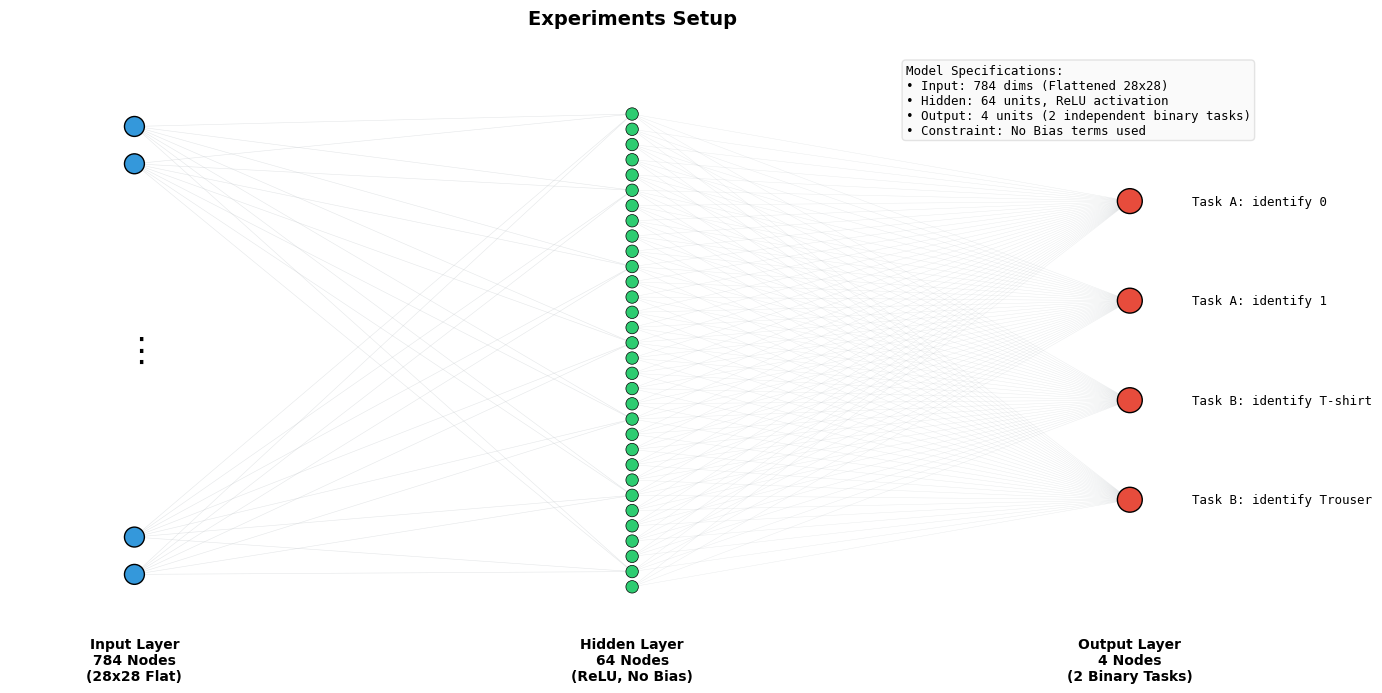

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, ConnectionPatch

def draw_neural_net():
    # 设置绘图区域
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(-0.5, 4.5)
    ax.set_ylim(-1.2, 1.2)
    ax.axis('off')
    ax.set_aspect('equal')

    # 网络结构定义
    layer_dims = [784, 64, 4]
    
    # 各层在 x 轴的位置
    x_input = 0
    x_hidden = 2.0
    x_output = 4.0
    
    # 颜色定义
    color_input = '#3498db'   # 蓝色
    color_hidden = '#2ecc71'  # 绿色
    color_output = '#e74c3c'  # 红色
    color_line = '#bdc3c7'    # 灰色连线

    # --- 1. 绘制输入层 (784维 -> 视觉简化) ---
    # 由于784个点太密，我们只画顶部2个、底部2个，中间用省略号
    y_in_top = 0.9
    y_in_bottom = -0.9
    gap_in = 0.15
    
    input_nodes_y = [y_in_top, y_in_top - gap_in, y_in_bottom + gap_in, y_in_bottom]
    
    for y in input_nodes_y:
        circle = Circle((x_input, y), 0.04, color=color_input, ec='black', lw=1, zorder=10)
        ax.add_patch(circle)
    
    # 添加省略号
    ax.text(x_input, 0, r'$\vdots$', fontsize=24, ha='center', va='center', fontweight='bold')
    ax.text(x_input, -1.15, f"Input Layer\n{layer_dims[0]} Nodes\n(28x28 Flat)", 
            ha='center', va='top', fontsize=10, fontweight='bold')

    # --- 2. 绘制隐藏层 (64维) ---
    # 64个点均匀分布
    n_hidden = 32
    y_hidden_start = 0.95
    y_hidden_end = -0.95
    hidden_nodes_y = np.linspace(y_hidden_start, y_hidden_end, n_hidden)
    
    for y in hidden_nodes_y:
        circle = Circle((x_hidden, y), 0.025, color=color_hidden, ec='black', lw=0.5, zorder=10)
        ax.add_patch(circle)
        
    ax.text(x_hidden, -1.15, f"Hidden Layer\n{layer_dims[1]} Nodes\n(ReLU, No Bias)", 
            ha='center', va='top', fontsize=10, fontweight='bold')

    # --- 3. 绘制输出层 (4维) ---
    n_output = layer_dims[2]
    output_labels = ["Task A: identify 0", "Task A: identify 1", "Task B: identify T-shirt", "Task B: identify Trouser"]    
    output_nodes_y = np.linspace(0.6, -0.6, n_output)
    
    for i, y in enumerate(output_nodes_y):
        circle = Circle((x_output, y), 0.05, color=color_output, ec='black', lw=1, zorder=10)
        ax.add_patch(circle)
        # 输出标签
        ax.text(x_output + 0.25, y, output_labels[i], fontsize=9, va='center', fontfamily='monospace')

    ax.text(x_output, -1.15, f"Output Layer\n{layer_dims[2]} Nodes\n(2 Binary Tasks)", 
            ha='center', va='top', fontsize=10, fontweight='bold')

    # --- 4. 绘制连接线 (权重) ---
    # 修正点：使用 add_patch 而不是 add_line
    
    # A. 输入层 -> 隐藏层 (稀疏采样，避免过密)
    # 选取输入层的代表点 (顶部2个，底部2个)
    # 选取隐藏层的代表点 (每隔5个取一个)
    sample_hidden_indices = range(0, n_hidden, 5) 
    
    for y_in in input_nodes_y:
        for idx in sample_hidden_indices:
            y_hid = hidden_nodes_y[idx]
            # 创建连接补丁
            con = ConnectionPatch(xyA=(x_hidden, y_hid), xyB=(x_input, y_in),
                                  coordsA="data", coordsB="data",
                                  linewidth=0.4, color=color_line, alpha=0.4)
            ax.add_patch(con) # 【修正处】这里必须用 add_patch

    # B. 隐藏层 -> 输出层 (全部绘制，因为数量可控 64*4=256)
    # 为了视觉清晰，降低透明度
    for y_hid in hidden_nodes_y:
        for y_out in output_nodes_y:
            con = ConnectionPatch(xyA=(x_output, y_out), xyB=(x_hidden, y_hid),
                                  coordsA="data", coordsB="data",
                                  linewidth=0.3, color=color_line, alpha=0.35)
            ax.add_patch(con) # 【修正处】这里必须用 add_patch

    # --- 标题与图例 ---
    plt.title("Experiments Setup", 
              fontsize=14, pad=20, fontweight='bold')
    
    # 添加说明框
    info_text = (
        "Model Specifications:\n"
        "• Input: 784 dims (Flattened 28x28)\n"
        "• Hidden: 64 units, ReLU activation\n"
        "• Output: 4 units (2 independent binary tasks)\n"
        "• Constraint: No Bias terms used"
    )
    props = dict(boxstyle='round', facecolor='#f9f9f9', edgecolor='#ddd', alpha=0.8)
    ax.text(0.72, 0.98, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props, fontfamily='monospace')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    try:
        draw_neural_net()
    except Exception as e:
        print(f"Error occurred: {e}")
        print("Please ensure you have matplotlib installed: pip install matplotlib")